In [54]:
%pip install pandas matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [56]:
data = {
    "message": [
        "Congratulations you won a free lottery prize",
        "Win cash now click this link",
        "You have won 10000 dollars claim now",
        "Free entry in a lucky draw",
        "Get a free mobile phone today",
        "Congratulations your number won a prize",
        "Claim your free reward now",
        "You are selected for a cash prize",
        "Win a brand new car today",
        "Click here to get your free gift",

        "Hi, how are you doing today",
        "Please send me the assignment",
        "Can we meet tomorrow morning",
        "Your class starts at 9 AM",
        "Don't forget to bring your laptop",
        "Can you call me when you are free",
        "The meeting is scheduled for tomorrow",
        "Please submit the project today",
        "I will send the notes tonight",
        "See you at college tomorrow"
    ],

    "label": [
        "spam", "spam", "spam", "spam", "spam",
        "spam", "spam", "spam", "spam", "spam",
        "ham", "ham", "ham", "ham", "ham",
        "ham", "ham", "ham", "ham", "ham"
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


Dataset:
                                         message label
0   Congratulations you won a free lottery prize  spam
1                   Win cash now click this link  spam
2           You have won 10000 dollars claim now  spam
3                     Free entry in a lucky draw  spam
4                  Get a free mobile phone today  spam
5        Congratulations your number won a prize  spam
6                     Claim your free reward now  spam
7              You are selected for a cash prize  spam
8                      Win a brand new car today  spam
9               Click here to get your free gift  spam
10                   Hi, how are you doing today   ham
11                 Please send me the assignment   ham
12                  Can we meet tomorrow morning   ham
13                     Your class starts at 9 AM   ham
14             Don't forget to bring your laptop   ham
15             Can you call me when you are free   ham
16         The meeting is scheduled for tomorrow   ham
1

In [57]:
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nLabel Counts:")
print(df["label"].value_counts())


First 5 rows:
                                        message label
0  Congratulations you won a free lottery prize  spam
1                  Win cash now click this link  spam
2          You have won 10000 dollars claim now  spam
3                    Free entry in a lucky draw  spam
4                 Get a free mobile phone today  spam

Dataset Shape:
(20, 2)

Label Counts:
label
spam    10
ham     10
Name: count, dtype: int64


In [58]:
X = df["message"]
y = df["label"]

print("Messages:")
print(X)

print("\nLabels:")
print(y)


Messages:
0     Congratulations you won a free lottery prize
1                     Win cash now click this link
2             You have won 10000 dollars claim now
3                       Free entry in a lucky draw
4                    Get a free mobile phone today
5          Congratulations your number won a prize
6                       Claim your free reward now
7                You are selected for a cash prize
8                        Win a brand new car today
9                 Click here to get your free gift
10                     Hi, how are you doing today
11                   Please send me the assignment
12                    Can we meet tomorrow morning
13                       Your class starts at 9 AM
14               Don't forget to bring your laptop
15               Can you call me when you are free
16           The meeting is scheduled for tomorrow
17                 Please submit the project today
18                   I will send the notes tonight
19                   

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)


Training data:
5          Congratulations your number won a prize
15               Can you call me when you are free
3                       Free entry in a lucky draw
19                     See you at college tomorrow
1                     Win cash now click this link
8                        Win a brand new car today
10                     Hi, how are you doing today
18                   I will send the notes tonight
7                You are selected for a cash prize
4                    Get a free mobile phone today
12                    Can we meet tomorrow morning
0     Congratulations you won a free lottery prize
11                   Please send me the assignment
17                 Please submit the project today
Name: message, dtype: str

Testing data:
14        Don't forget to bring your laptop
9          Click here to get your free gift
13                Your class starts at 9 AM
6                Claim your free reward now
2      You have won 10000 dollars claim now
16    The 

In [60]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (14, 51)
Testing TF-IDF shape: (6, 51)


In [61]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")


Model training completed successfully!


In [62]:
y_pred = model.predict(X_test_tfidf)

print("Actual Labels:")
print(y_test.values)

print("\nPredicted Labels:")
print(y_pred)


Actual Labels:
<StringArray>
['ham', 'spam', 'ham', 'spam', 'spam', 'ham']
Length: 6, dtype: str

Predicted Labels:
['spam' 'spam' 'spam' 'spam' 'spam' 'ham']


In [63]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")


Accuracy: 66.66666666666666 %


In [64]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         ham       1.00      0.33      0.50         3
        spam       0.60      1.00      0.75         3

    accuracy                           0.67         6
   macro avg       0.80      0.67      0.62         6
weighted avg       0.80      0.67      0.62         6



In [65]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1 2]
 [0 3]]


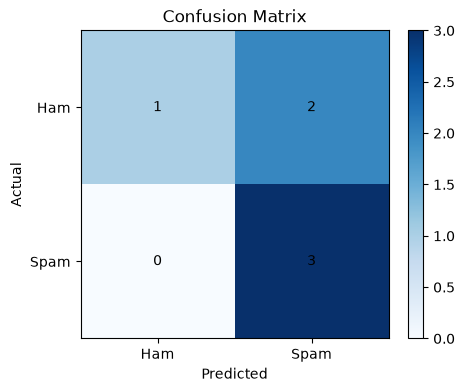

In [66]:
plt.figure(figsize=(5, 4))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
plt.show()


In [67]:
messages = [
    "Congratulations you won a free prize click now",
    "Please send me your class notes",
    "You have won 50000 dollars claim your reward",
    "Can we meet tomorrow at college"
]

messages_tfidf = vectorizer.transform(messages)

predictions = model.predict(messages_tfidf)

print("Message Predictions:")

for message, prediction in zip(messages, predictions):
    print("\nMessage:", message)
    print("Prediction:", prediction.upper())


Message Predictions:

Message: Congratulations you won a free prize click now
Prediction: SPAM

Message: Please send me your class notes
Prediction: HAM

Message: You have won 50000 dollars claim your reward
Prediction: SPAM

Message: Can we meet tomorrow at college
Prediction: HAM


In [68]:
new_message = [
    "You have won a free iPhone, claim it now"
]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

print("Message:", new_message[0])
print("Prediction:", prediction[0].upper())


Message: You have won a free iPhone, claim it now
Prediction: SPAM


In [69]:
import joblib
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(model, 'model.pkl')

['model.pkl']